# TP Simulación · Estrategia de trading entrenada con datos simulados
### Bitcoin · bootstrap por bloques · cruce de medias móviles

Métodos Predictivos Aplicados a las Finanzas – Parte II · UBA · Docente: Ezequiel Nuske · **Giovanni Raffo**

**Consigna:** elegir un activo, dividirlo en entrenamiento y prueba, simular los datos con bootstrap, entrenar una estrategia de trading simple con los datos simulados y evaluarla en la serie original, en entrenamiento y en prueba.

## 1. Activo y datos

Bitcoin (BTC-USD), precio de cierre diario de Yahoo Finance desde enero de 2020, como en la clase. Las fechas quedan fijas para que el resultado sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

datos = yf.download("BTC-USD", start="2020-01-01", end="2026-09-23", auto_adjust=True, progress=False)
precios = datos["Close"].squeeze().interpolate()
print("Días:", len(precios))

Días: 2457


## 2. Entrenamiento y prueba

Entrenamiento: 2020 a 2024. Prueba: 2025 y 2026, que la estrategia no ve hasta la evaluación final.

In [2]:
entrenamiento = precios[:"2024-12-31"]
prueba = precios["2025-01-01":]
print("Entrenamiento:", len(entrenamiento), "días | Prueba:", len(prueba), "días")

Entrenamiento: 1827 días | Prueba: 630 días


## 3. Datos simulados: bootstrap por bloques

Como en la clase, se toman los rendimientos diarios del **entrenamiento** y se rearman en un orden al azar, en bloques de 10 días seguidos. Cada bloque conserva cómo se mueve Bitcoin en el corto plazo. Con los rendimientos rearmados se reconstruye un precio. Se generan 1.000 caminos simulados.

In [3]:
rng = np.random.default_rng(42)
rendimientos = np.log(entrenamiento).diff().dropna().values

def bootstrap(bloque=10):
    inicios = rng.integers(0, len(rendimientos) - bloque, len(rendimientos) // bloque + 1)
    return np.concatenate([rendimientos[i:i + bloque] for i in inicios])[:len(rendimientos)]

caminos = [np.exp(np.cumsum(np.insert(bootstrap(), 0, 0))) for _ in range(1000)]
simulados = pd.DataFrame(np.array(caminos).T * entrenamiento.iloc[0], index=entrenamiento.index)

pd.DataFrame({
    "Bitcoin real": [entrenamiento.pct_change().mean() * 365, entrenamiento.pct_change().std() * np.sqrt(365)],
    "Simulados (promedio)": [simulados.pct_change().mean().mean() * 365, simulados.pct_change().std().mean() * np.sqrt(365)],
}, index=["Rendimiento anual medio", "Volatilidad anual"]).round(3)

,Bitcoin real,Simulados (promedio)
Rendimiento anual medio,0.722,0.724
Volatilidad anual,0.641,0.642


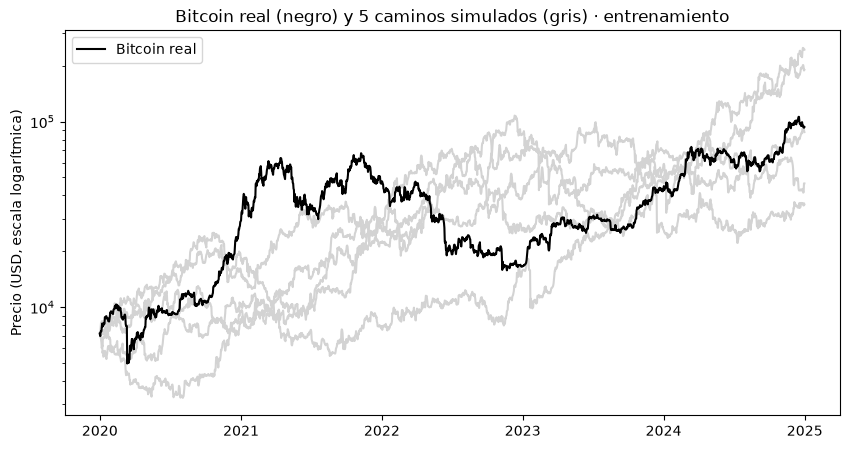

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(simulados.iloc[:, :5], color="lightgray")
plt.plot(entrenamiento, color="black", label="Bitcoin real")
plt.yscale("log")
plt.title("Bitcoin real (negro) y 5 caminos simulados (gris) · entrenamiento")
plt.ylabel("Precio (USD, escala logarítmica)")
plt.legend()
plt.show()

**Lectura:** los simulados conservan las características fundamentales de Bitcoin: el mismo rendimiento medio (72 % anual) y la misma volatilidad (64 % anual). Cada camino es una historia distinta que Bitcoin pudo haber tenido.

## 4. Estrategia entrenada con los datos simulados

**Cruce de medias móviles**, la estrategia simple de la clase: se está comprado cuando el promedio de los últimos días (media corta) está por encima del promedio de un período más largo (media larga), y fuera del mercado cuando está por debajo. La decisión de cada día usa solo precios hasta el día anterior.

Se prueban las mismas combinaciones de la clase: media corta de 2 a 9 días y media larga de 20 a 45 días (48 combinaciones). Cada una se aplica a los 1.000 caminos simulados y se elige la de mayor **Sharpe Ratio** promedio: rendimiento dividido por volatilidad, anualizado.

In [5]:
def estrategia(precios, corta, larga):
    comprado = (precios.rolling(corta).mean() > precios.rolling(larga).mean()).astype(int)
    return comprado.shift(1) * precios.pct_change()

def sharpe(r):
    return r.mean() / r.std() * np.sqrt(365)

filas = []
for corta in range(2, 10):
    for larga in range(20, 50, 5):
        filas.append([corta, larga, sharpe(estrategia(simulados, corta, larga)).mean()])
grilla = pd.DataFrame(filas, columns=["corta", "larga", "sharpe"])

mejor = grilla.loc[grilla["sharpe"].idxmax()]
mejor_corta, mejor_larga = int(mejor["corta"]), int(mejor["larga"])
print("Mejor combinación: media corta", mejor_corta, "días y media larga", mejor_larga, "días | Sharpe promedio:", round(mejor["sharpe"], 2))
print("Referencia, comprar y mantener en los simulados:", round(sharpe(simulados.pct_change()).mean(), 2))

Mejor combinación: media corta 2 días y media larga 20 días | Sharpe promedio: 0.99
Referencia, comprar y mantener en los simulados: 1.13


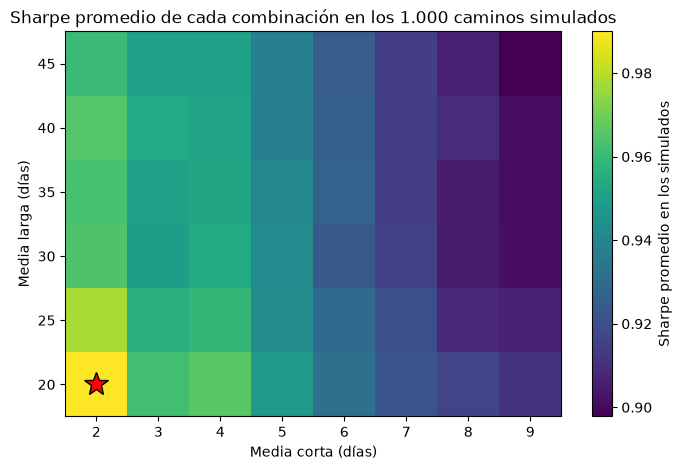

In [6]:
tabla = grilla.pivot_table("sharpe", "larga", "corta")
plt.figure(figsize=(8, 5))
plt.pcolormesh(tabla.columns, tabla.index, tabla, shading="nearest")
plt.colorbar(label="Sharpe promedio en los simulados")
plt.plot(mejor_corta, mejor_larga, "*", color="red", markeredgecolor="black", markersize=18)
plt.title("Sharpe promedio de cada combinación en los 1.000 caminos simulados")
plt.xlabel("Media corta (días)")
plt.ylabel("Media larga (días)")
plt.show()

**Lectura:** la mejor combinación es una media corta de 2 días y una larga de 20 días. Las mejores combinaciones usan medias cortas muy rápidas y quedan cerca entre sí. En los simulados ninguna combinación supera en Sharpe a comprar y mantener: el bootstrap por bloques mezcla el orden de los rendimientos y borra las tendencias largas que la estrategia busca aprovechar.

## 5. Evaluación en la serie real

Se aplica la combinación elegida a Bitcoin real, en entrenamiento y en prueba, y se compara con comprar y mantener. Las medias del inicio de la prueba usan los últimos precios del entrenamiento: solo información pasada.

- **Retorno acumulado:** cuánto ganó 1 USD invertido al inicio del período.
- **Sharpe:** rendimiento por unidad de volatilidad, anualizado.
- **Máxima caída:** la peor pérdida desde un máximo previo.

In [7]:
r_estrategia = estrategia(precios, mejor_corta, mejor_larga)
r_mantener = precios.pct_change()
periodos = {"Entrenamiento 2020-2024": slice("2020", "2024"), "Prueba 2025-2026": slice("2025", "2026")}

def metricas(r):
    valor = (1 + r.fillna(0)).cumprod()
    return [(valor.iloc[-1] - 1) * 100, sharpe(r), (valor / valor.cummax() - 1).min() * 100]

filas = []
for periodo, fechas in periodos.items():
    filas.append([periodo, "Estrategia"] + metricas(r_estrategia[fechas]))
    filas.append([periodo, "Comprar y mantener"] + metricas(r_mantener[fechas]))
pd.DataFrame(filas, columns=["Período", "Estrategia", "Retorno acumulado (%)", "Sharpe", "Máxima caída (%)"]).round(2)

,Período,Estrategia,Retorno acumulado (%),Sharpe,Máxima caída (%)
0,Entrenamiento 2020-2024,Estrategia,794.13,1.24,-53.24
1,Entrenamiento 2020-2024,Comprar y mantener,1197.60,1.13,-76.63
2,Prueba 2025-2026,Estrategia,27.58,0.67,-27.90
3,Prueba 2025-2026,Comprar y mantener,-7.77,0.11,-53.06


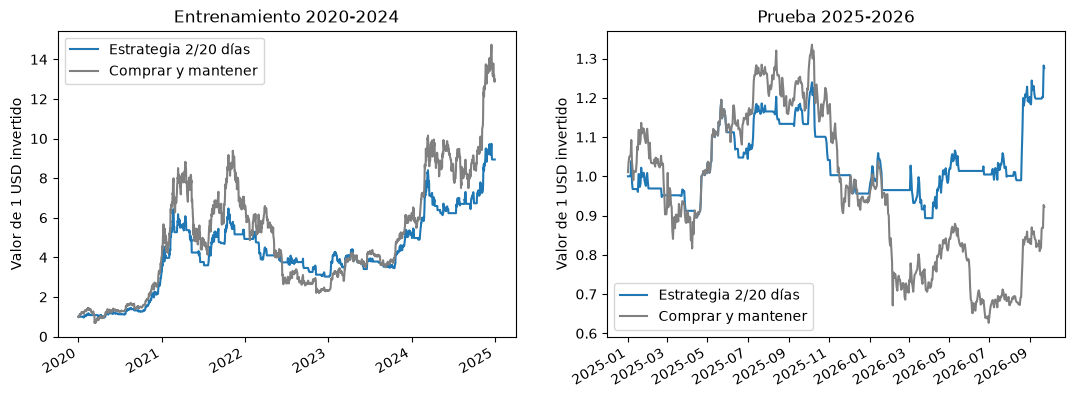

In [8]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (periodo, fechas) in zip(ejes, periodos.items()):
    ax.plot((1 + r_estrategia[fechas].fillna(0)).cumprod(), label=f"Estrategia {mejor_corta}/{mejor_larga} días")
    ax.plot((1 + r_mantener[fechas].fillna(0)).cumprod(), label="Comprar y mantener", color="gray")
    ax.set(title=periodo, ylabel="Valor de 1 USD invertido")
    ax.legend()
fig.autofmt_xdate()
plt.show()

**Lectura:**
- **Entrenamiento:** la estrategia gana menos que comprar y mantener (794 % contra 1.198 %), pero con mejor Sharpe (1,24 contra 1,13) y una caída máxima mucho menor (−53 % contra −77 %): se pierde parte de la suba a cambio de esquivar las peores caídas.
- **Prueba:** la estrategia gana 27,6 % mientras que comprar y mantener pierde 7,8 %, con mejor Sharpe (0,67 contra 0,11) y la mitad de la caída máxima (−28 % contra −53 %).

## 6. Cierre

| Punto de la consigna | Qué se hizo |
|---|---|
| Elegir un activo | Bitcoin (BTC-USD), precios diarios desde 2020 |
| Entrenamiento y prueba | Entrenamiento 2020-2024, prueba 2025-2026 |
| Simular o hacer bootstrap | Bootstrap por bloques de 10 días: 1.000 caminos con el mismo rendimiento y volatilidad que Bitcoin |
| Entrenar una estrategia simple | Cruce de medias móviles; 48 combinaciones evaluadas en los simulados; elegida la de 2 y 20 días |
| Evaluar en la serie original | Entrenamiento y prueba, contra comprar y mantener |
| Presentar resultados | Retorno acumulado, Sharpe y máxima caída, con gráficos |

**Conclusión:** la estrategia elegida solo con datos simulados funciona en la serie real. En la prueba, que nunca vio, gana 27,6 % frente a una pérdida de 7,8 % de comprar y mantener, con menos riesgo. Su valor está más en reducir las caídas que en ganar más en las subas. No se consideran costos de transacción.